# Decision Boundary Visualization

Train an MLP on a non-linear dataset and visualize decision boundary.

## Concepts
- Non-linear classification
- Model generalization
- Visualization

In [1]:
from src.nn import MLP
from src.utils import make_moons_dataset, plot_decision_boundary


## Dataset

In [2]:
X, y = make_moons_dataset(200, noise=0.2)
y = y * 2 - 1

## Model

In [3]:
model = MLP(2, [16,16,1])

## Training

In [4]:
## Training
for epoch in range(50):
    total_loss = 0

    for xi, yi in zip(X, y):
        model.zero_grad()

        # FIX: Remove the [0] because your model returns the Value object directly
        pred = model(list(xi)) 
        
        # Now pred is a Value object, so you can subtract yi from it
        loss = (pred - yi)**2

        # pred = model(list(xi)) # Returns a Value object
        # loss = (pred - yi)**2

        loss.backward()

        # Update weights (Stochastic Gradient Descent)
        for p in model.parameters():
            p.data -= 0.01 * p.grad

        total_loss += loss.data
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss {total_loss:.4f}")

Epoch 0: Loss 721.0888
Epoch 10: Loss 444.1550
Epoch 20: Loss 425.6367
Epoch 30: Loss 433.8545
Epoch 40: Loss 420.3800


## Visualization

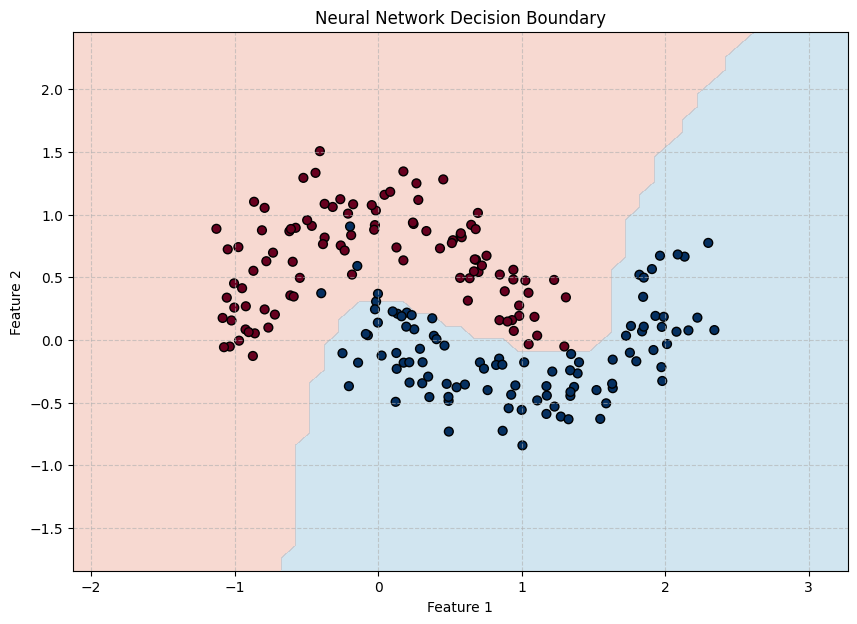

In [5]:
plot_decision_boundary(model, X, y)